**3. Exploratory Data Analysis & Competitive Benchmark**

In [ ]:
!pip install gdown

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1RjkYFQ1Bd_Vg1FapeeD_Svc_i-7cCFG5

Retrieving folder contents
Processing file 160ll1z23ktLq5mfeIdd8PI7aKqgXRNqm Batdongsan_clean_ver1.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=160ll1z23ktLq5mfeIdd8PI7aKqgXRNqm
To: /content/Data_clean/Batdongsan_clean_ver1.csv
100% 5.98M/5.98M [00:00<00:00, 25.0MB/s]
Download completed


In [ ]:
import pandas as pd

eda_df = pd.read_csv("Data_clean/Batdongsan_clean_ver1.csv")

eda_df.head()

,brand,project,city,url,title,price_vnd,area_m2,price_per_m2,bedrooms,bathrooms,...,dist_highway_km,dist_airport_km,has_mall,has_school,has_hospital,has_park,has_pool,launch_year,handover_year,ownership
0,Novaland,lucky dragon,Tphcm,https://batdongsan.com.vn/ban-can-ho-chung-cu-...,Bán căn hộ tầng 10 chung cư Lucky Dragon tại 3...,6.100000e+09,75.6,80687830.0,2.0,2.0,...,3.0,15.0,True,False,False,True,True,2014,2016.0,Lâu dài
1,Novaland,lucky dragon,Tphcm,https://batdongsan.com.vn/ban-can-ho-chung-cu-...,"GIẢM 500 TRIỆU CHỈ CÒN 4,95 TỶ - BÁN CĂN HỘ LU...",4.950000e+09,75.2,65824468.0,2.0,2.0,...,3.0,15.0,True,False,False,True,True,2014,2016.0,Lâu dài
2,Novaland,lucky dragon,Tphcm,https://batdongsan.com.vn/ban-can-ho-chung-cu-...,"Bán căn hộ Lucky Dragon, Đỗ Xuân Hợp, Quận 9 c...",5.100000e+09,72.0,70833333.0,2.0,2.0,...,3.0,15.0,True,False,False,True,True,2014,2016.0,Lâu dài
3,Novaland,gardengate,Ho Chi Minh City,https://batdongsan.com.vn/ban-can-ho-chung-cu-...,"Bán căn hộ 2PN Garden Gate, Hoàng Minh Giám, 7...",7.400000e+09,72.0,102777777.0,2.0,2.0,...,0.5,1.0,False,False,False,True,True,2014,2017.0,Lâu dài
4,Novaland,gardengate,Ho Chi Minh City,https://batdongsan.com.vn/ban-can-ho-chung-cu-...,Mình cần bán nhanh căn hộ Garden Gate Hoàng Mi...,9.300000e+09,105.0,88571428.0,NaN,NaN,...,0.5,1.0,False,False,False,True,True,2014,2017.0,Lâu dài


In [ ]:
vin_blue = "#0B3A82"
vin_gold = "#C9A961"
vin_dark = "#333333"
vin_light = "#E6E6E6"
vin_palette = [vin_blue, vin_gold, vin_dark]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

vin_blue = "#0B3A82"
vin_gold = "#C9A961"
vin_dark = "#333333"
vin_light = "#E6E6E6"

sns.set_style("whitegrid")
sns.set_palette([vin_blue, vin_gold, vin_dark])

**3.1 Digital Marketplace Presence Analysis**

Phân tích mức độ nhận diện của Vinhomes trên market place

**3.1.1 Brand Listing Share**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def bar_chart_with_labels(x, y, title, xlabel, ylabel, color):

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        x=x,
        y=y,
        color=color
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)

    # add value labels
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.0f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.show()

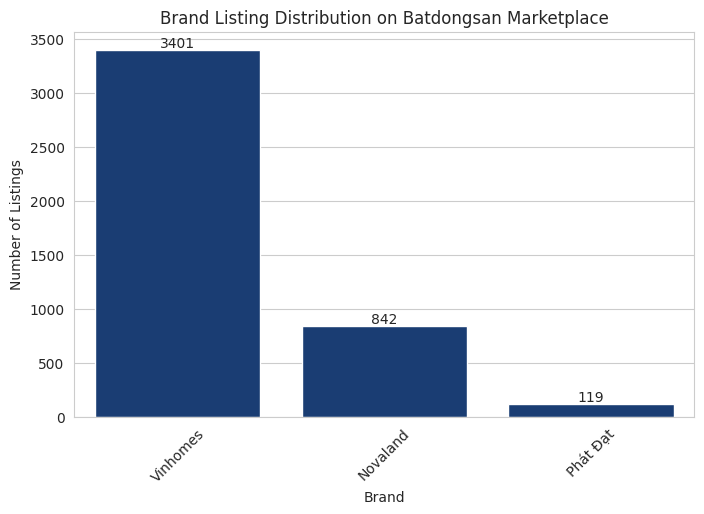

In [ ]:
brand_counts = eda_df['brand'].value_counts()

bar_chart_with_labels(
    brand_counts.index,
    brand_counts.values,
    "Brand Listing Distribution on Batdongsan Marketplace",
    "Brand",
    "Number of Listings",
    vin_blue
)

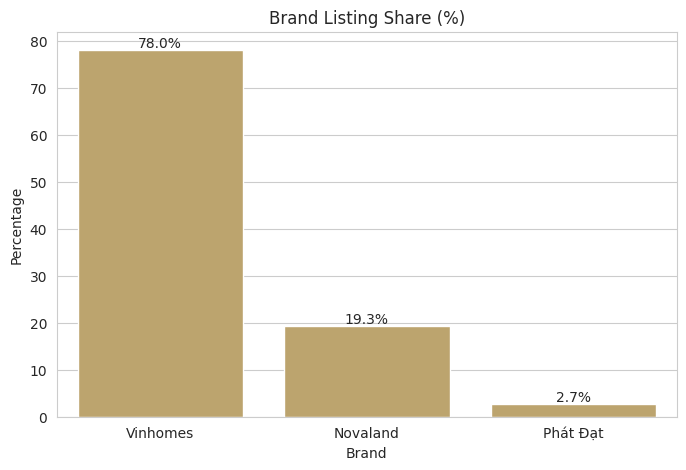

In [ ]:
brand_share = eda_df['brand'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=brand_share.index,
    y=brand_share.values,
    color=vin_gold
)

plt.title("Brand Listing Share (%)")
plt.xlabel("Brand")
plt.ylabel("Percentage")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

**3.1.2 Listing Premium Strategy**

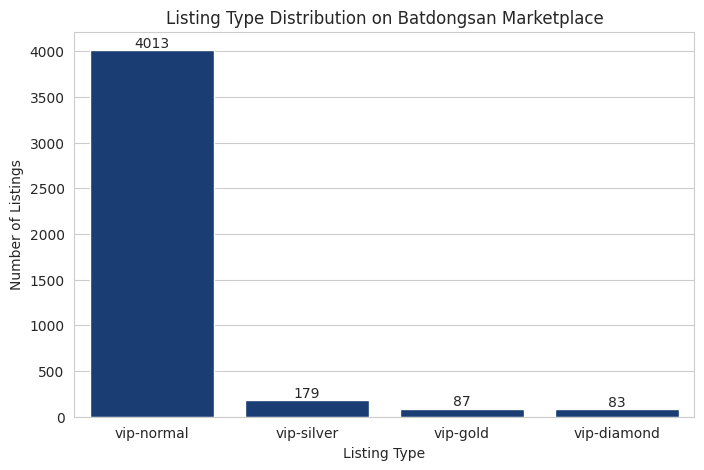

In [ ]:
listing_counts = eda_df['listing_type'].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=listing_counts.index,
    y=listing_counts.values,
    color=vin_blue
)

plt.title("Listing Type Distribution on Batdongsan Marketplace")
plt.xlabel("Listing Type")
plt.ylabel("Number of Listings")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

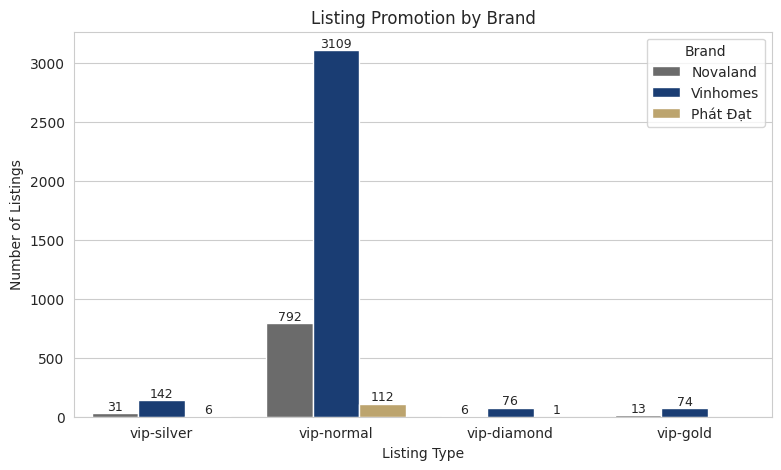

In [ ]:
brand_palette = {
    "Vinhomes": "#0B3A82",
    "Novaland": "#6B6B6B",
    "Phát Đạt": "#C9A961"
}

plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=eda_df,
    x='listing_type',
    hue='brand',
    palette=brand_palette
)

plt.title("Listing Promotion by Brand")
plt.xlabel("Listing Type")
plt.ylabel("Number of Listings")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.0f}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.legend(title="Brand")
plt.show()

**3.2.Listing Marketing Content Analysis**

**3.2.1 Keyword Positioning Analysis**

In [ ]:
eda_df["text_content"] = (
    eda_df["title"].fillna("") + " " +
    eda_df["description"].fillna("")
)

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-ZÀ-ỹ0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

eda_df["text_content"] = eda_df["text_content"].apply(clean_text)

In [ ]:
keyword_dict = {
    "luxury": ["cao cấp","sang trọng","luxury","đẳng cấp"],
    "river_view": ["view sông","ven sông","river view"],
    "investment": ["đầu tư","investment","sinh lời"],
    "modern_urban": ["thành phố thông minh","đô thị hiện đại","khu đô thị hiện đại"],
    "full_furniture": ["full nội thất","đầy đủ nội thất","full nt"],
    "high_floor": ["tầng cao","view thoáng"]
}

In [ ]:
for key, words in keyword_dict.items():
    eda_df[key] = eda_df["text_content"].apply(
        lambda x: any(w in x for w in words)
    )

In [ ]:
keyword_cols = list(keyword_dict.keys())

keyword_brand = eda_df.groupby("brand")[keyword_cols].sum()

keyword_brand

,luxury,river_view,investment,modern_urban,full_furniture,high_floor
brand,,,,,,
Novaland,294,62,206,0,317,174
Phát Đạt,59,10,14,0,55,23
Vinhomes,1296,326,1056,27,984,624


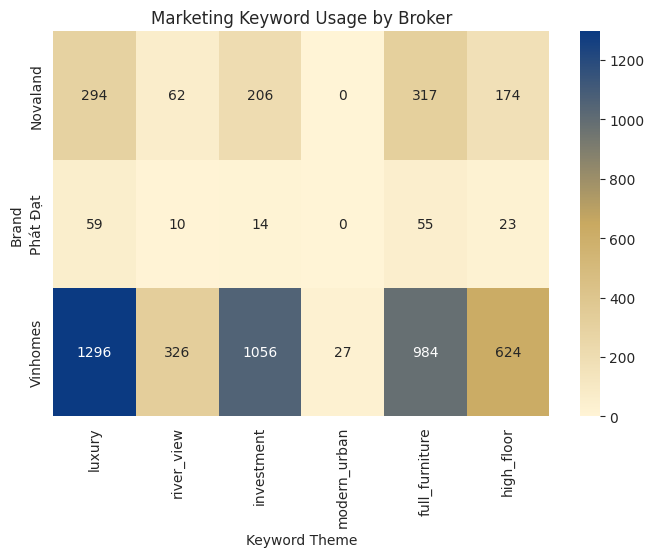

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
vinhomes_cmap = LinearSegmentedColormap.from_list(
    "vinhomes",
    ["#FFF4D6", "#C9A961", "#0B3A82"]
)
plt.figure(figsize=(8,5))

sns.heatmap(
    keyword_brand,
    annot=True,
    fmt=".0f",
    cmap=vinhomes_cmap
)

plt.title("Marketing Keyword Usage by Broker")
plt.xlabel("Keyword Theme")
plt.ylabel("Brand")

plt.show()


**3.2.2 Content Richness Analysis**

In [ ]:
eda_df["description_length"] = eda_df["description"].fillna("").apply(len)

In [ ]:
eda_df.groupby("brand")["description_length"].describe()

,count,mean,std,min,25%,50%,75%,max
brand,,,,,,,,
Novaland,842.0,623.077197,444.487387,35.0,304.0,476.5,810.0,2948.0
Phát Đạt,119.0,645.663866,318.779326,151.0,406.0,584.0,852.0,1593.0
Vinhomes,3401.0,683.092620,467.942648,42.0,327.0,582.0,936.0,2937.0


/tmp/ipykernel_868/3739962305.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


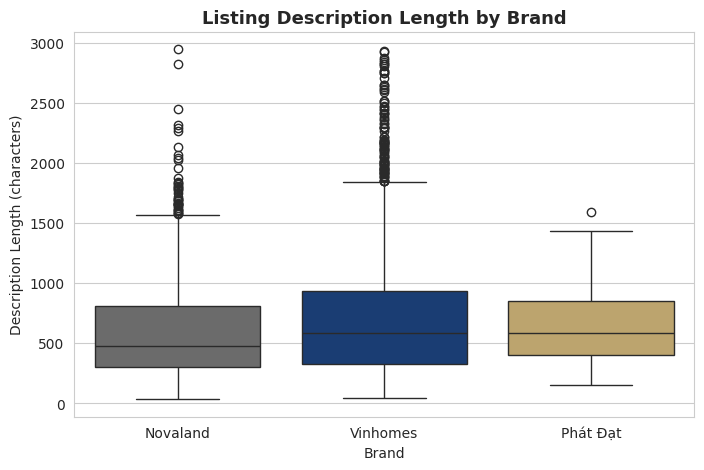

In [ ]:
brand_palette = {
    "Vinhomes": "#0B3A82",
    "Novaland": "#6B6B6B",
    "Phát Đạt": "#C9A961"
}
plt.figure(figsize=(8,5))
sns.boxplot(
    data=eda_df,
    x="brand",
    y="description_length",
    palette=brand_palette
)

plt.title("Listing Description Length by Brand", fontsize=13, weight="bold")
plt.xlabel("Brand")
plt.ylabel("Description Length (characters)")

plt.show()

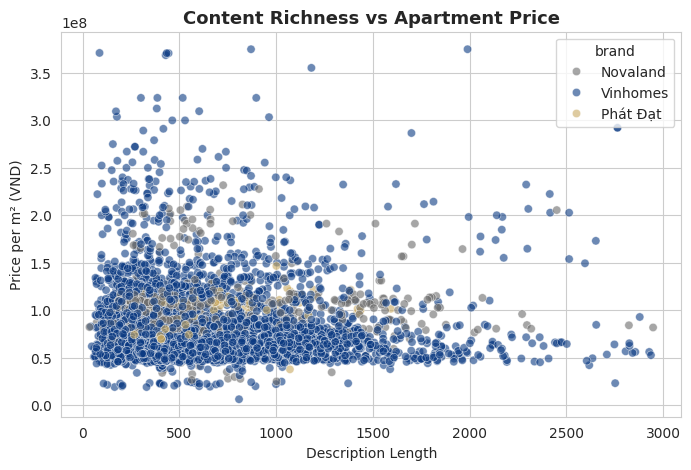

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=eda_df,
    x="description_length",
    y="price_per_m2",
    hue="brand",
    palette=brand_palette,
    alpha=0.6
)

plt.title("Content Richness vs Apartment Price", fontsize=13, weight="bold")
plt.xlabel("Description Length")
plt.ylabel("Price per m² (VND)")

plt.show()

**3.3.Product Structure Analysis**

**3.3.1 Apartment Size Distribution**

/tmp/ipykernel_868/2509154795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


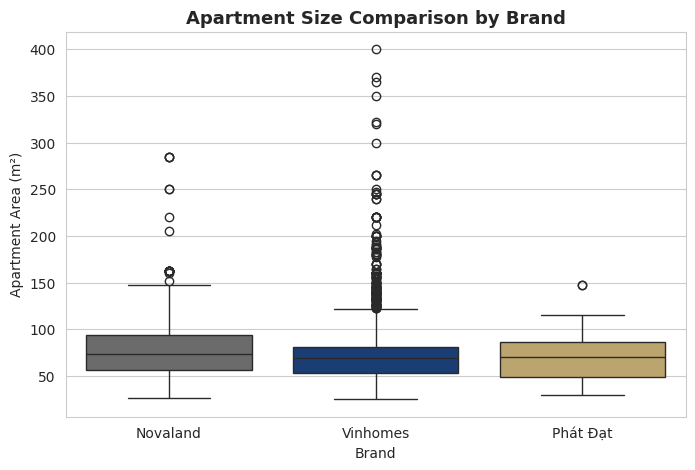

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="brand",
    y="area_m2",
    palette=brand_palette
)

plt.title("Apartment Size Comparison by Brand", fontsize=13, weight="bold")
plt.xlabel("Brand")
plt.ylabel("Apartment Area (m²)")

plt.show()

**3.3.2 Bedroom Structure**

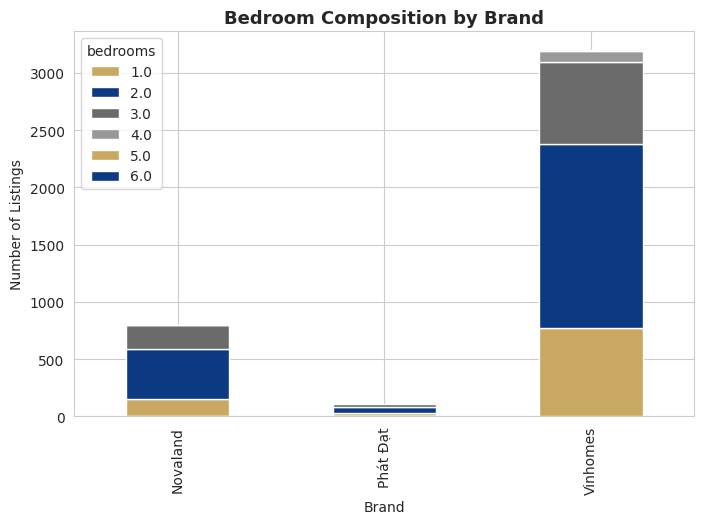

In [ ]:
bedroom_brand = pd.crosstab(eda_df["brand"], eda_df["bedrooms"])

bedroom_brand.plot(
    kind="bar",
    stacked=True,
    color=["#C9A961","#0B3A82","#6B6B6B","#999999"],
    figsize=(8,5)
)

plt.title("Bedroom Composition by Brand", fontsize=13, weight="bold")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")

plt.show()

**3.3.3 Project Scale Benchmark**

/tmp/ipykernel_868/52287953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


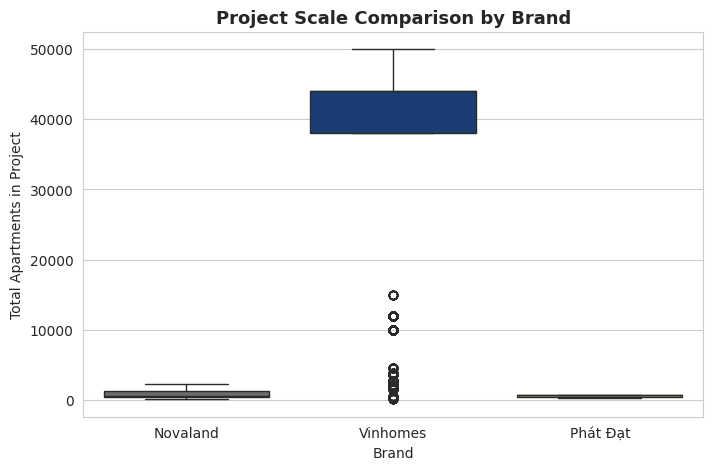

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="brand",
    y="total_apartment",
    palette=brand_palette
)

plt.title("Project Scale Comparison by Brand", fontsize=13, weight="bold")
plt.xlabel("Brand")
plt.ylabel("Total Apartments in Project")

plt.show()

**3.4.Competitive Price Benchmark**

**3.4.1 Price Positioning by Brand**

/tmp/ipykernel_868/2788912238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


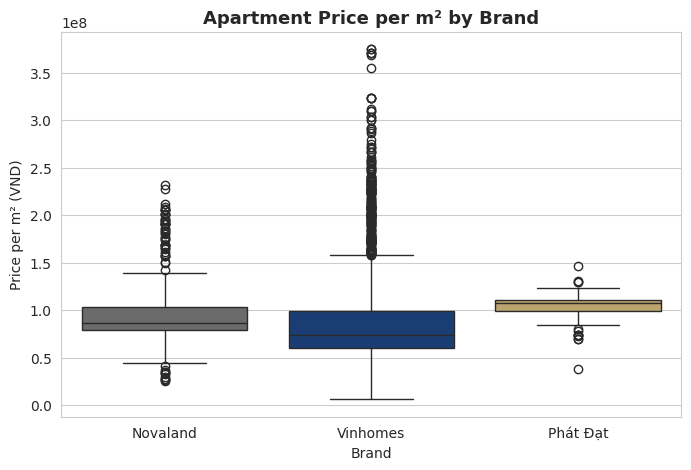

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="brand",
    y="price_per_m2",
    palette=brand_palette
)

plt.title("Apartment Price per m² by Brand", fontsize=13, weight="bold")
plt.xlabel("Brand")
plt.ylabel("Price per m² (VND)")

plt.show()

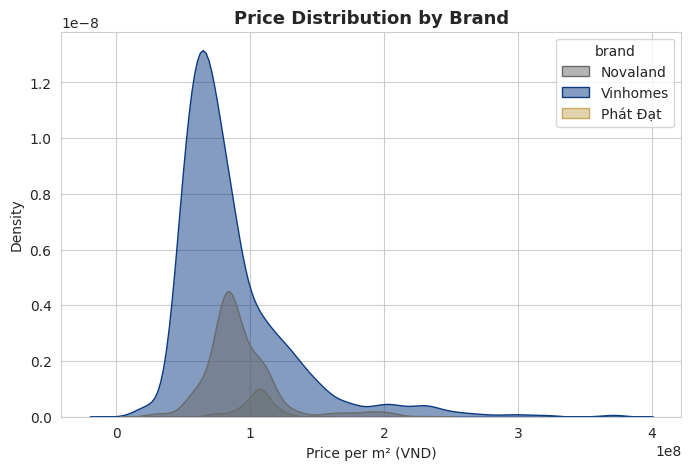

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=eda_df,
    x="price_per_m2",
    hue="brand",
    fill=True,
    palette=brand_palette,
    alpha=0.5
)

plt.title("Price Distribution by Brand", fontsize=13, weight="bold")
plt.xlabel("Price per m² (VND)")
plt.ylabel("Density")

plt.show()

In [ ]:
price_stats = eda_df.groupby("brand")["price_per_m2"].agg(
    mean_price="mean",
    median_price="median",
    std_price="std"
)

price_stats

,mean_price,median_price,std_price
brand,,,
Novaland,9.298724e+07,86363636.0,2.850407e+07
Phát Đạt,1.041011e+08,107558139.0,1.427917e+07
Vinhomes,8.718097e+07,73563218.0,4.409871e+07


**3.4.2 Location Advantage Analysis**

3.4.2.1 Distance to Key Urban Amenities

In [ ]:
distance_cols = [
    "dist_cbd_km",
    "dist_metro_km",
    "dist_river_lake_km",
    "dist_highway_km",
    "dist_airport_km"
]

distance_df = eda_df[["brand"] + distance_cols]

distance_long = distance_df.melt(
    id_vars="brand",
    var_name="distance_type",
    value_name="distance_km"
)

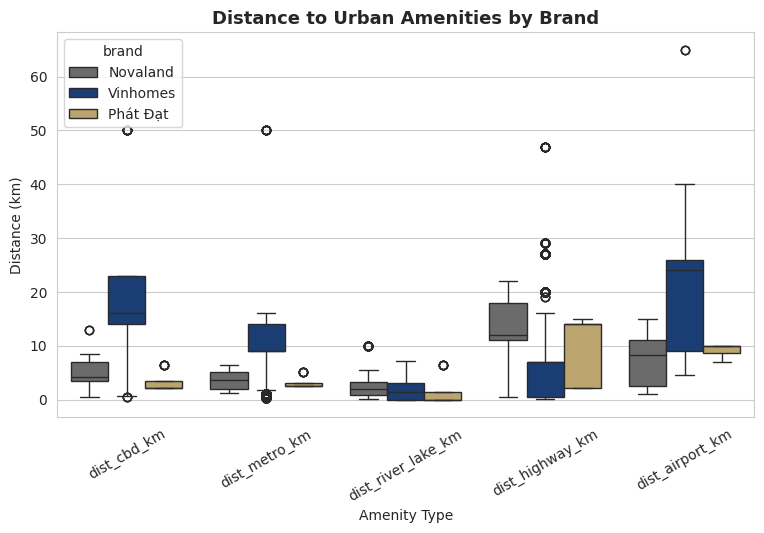

In [ ]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=distance_long,
    x="distance_type",
    y="distance_km",
    hue="brand",
    palette={
        "Vinhomes": "#0B3A82",
        "Novaland": "#6B6B6B",
        "Phát Đạt": "#C9A961"
    }
)

plt.title("Distance to Urban Amenities by Brand", fontsize=13, weight="bold")
plt.xlabel("Amenity Type")
plt.ylabel("Distance (km)")

plt.xticks(rotation=30)

plt.show()

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

vinhomes_corr = LinearSegmentedColormap.from_list(
    "vinhomes_corr",
    [
        "#C9A86A",
        "#E0E0E0",
        "#1f3b73"
    ]
)

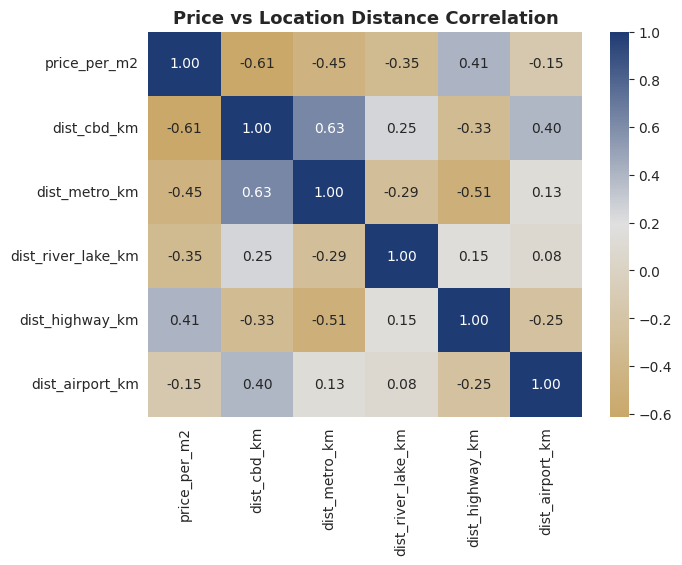

In [ ]:
distance_cols = [
    "price_per_m2",
    "dist_cbd_km",
    "dist_metro_km",
    "dist_river_lake_km",
    "dist_highway_km",
    "dist_airport_km"
]

corr_distance = eda_df[distance_cols].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr_distance,
    annot=True,
    fmt=".2f",
    cmap=vinhomes_corr
)

plt.title("Price vs Location Distance Correlation", fontsize=13, weight="bold")

plt.show()

3.4.2.2 Amenity Availability by Brand

In [ ]:
amenity_cols = [
    "has_mall",
    "has_school",
    "has_hospital",
    "has_park",
    "has_pool"
]

amenity_rate = eda_df.groupby("brand")[amenity_cols].mean() * 100

<Figure size 900x500 with 0 Axes>

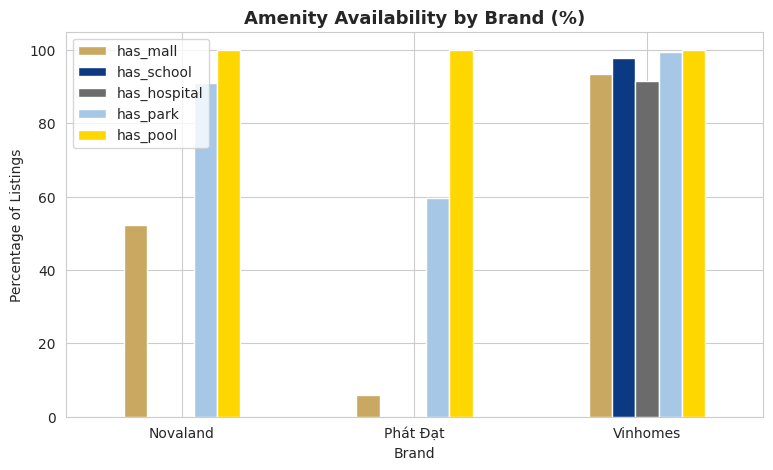

In [ ]:
plt.figure(figsize=(9,5))

amenity_rate.plot(
    kind="bar",
    color=["#C9A961","#0B3A82","#6B6B6B","#A7C7E7","#FFD700"],
    figsize=(9,5)
)

plt.title("Amenity Availability by Brand (%)", fontsize=13, weight="bold")
plt.xlabel("Brand")
plt.ylabel("Percentage of Listings")

plt.xticks(rotation=0)

plt.show()

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

vinhomes_corr = LinearSegmentedColormap.from_list(
    "vinhomes_corr",
    ["#C9A961", "#B0B0B0", "#0B3A82"]
)

In [ ]:
amenity_cols = [
    "has_mall",
    "has_school",
    "has_hospital",
    "has_park",
    "has_pool"
]

amenity_df = eda_df[["price_per_m2"] + amenity_cols]

amenity_long = amenity_df.melt(
    id_vars="price_per_m2",
    var_name="amenity",
    value_name="has_amenity"
)

In [ ]:
amenity_cols = [
    "has_mall",
    "has_school",
    "has_hospital",
    "has_park",
    "has_pool"
]

eda_df["amenity_score"] = eda_df[amenity_cols].sum(axis=1)

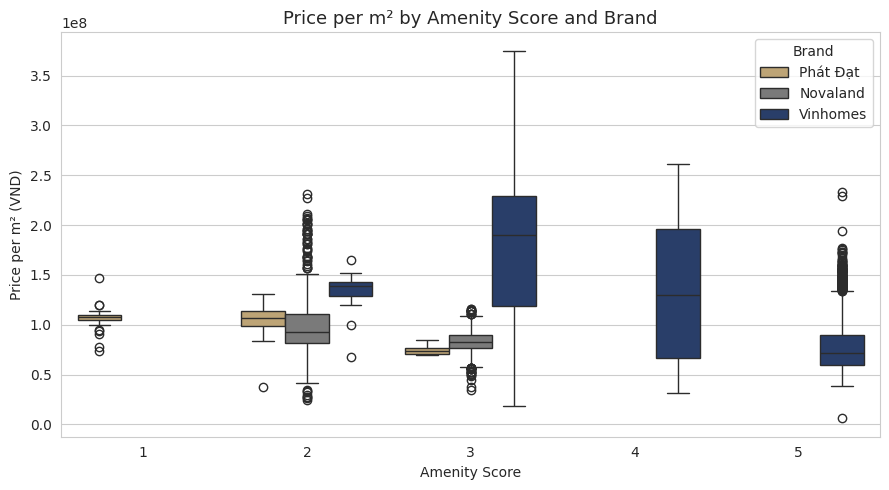

In [ ]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=eda_df,
    x="amenity_score",
    y="price_per_m2",
    hue="brand",
    palette={
        "Vinhomes": "#1f3b73",   # navy
        "Novaland": "#7a7a7a",   # grey
        "Phát Đạt": "#C9A86A"    # gold
    }
)

plt.title("Price per m² by Amenity Score and Brand", fontsize=13)
plt.xlabel("Amenity Score")
plt.ylabel("Price per m² (VND)")

plt.legend(title="Brand")
plt.tight_layout()
plt.show()

**3.5 Market Segmentation & Opportunity Identification**

**3.5.1 Apartment Market Segmentation (K-means)**

In [ ]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "area_m2",
    "price_per_m2",
    "dist_cbd_km",
    "bedrooms",
    "amenity_score"
]

cluster_df = eda_df[cluster_features].dropna()

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_df)

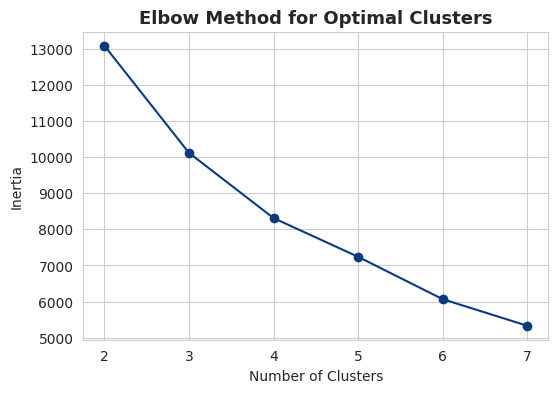

In [ ]:
from sklearn.cluster import KMeans

inertia = []

k_range = range(2,8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))

plt.plot(k_range, inertia, marker="o", color="#0B3A82")

plt.title("Elbow Method for Optimal Clusters", fontsize=13, weight="bold")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

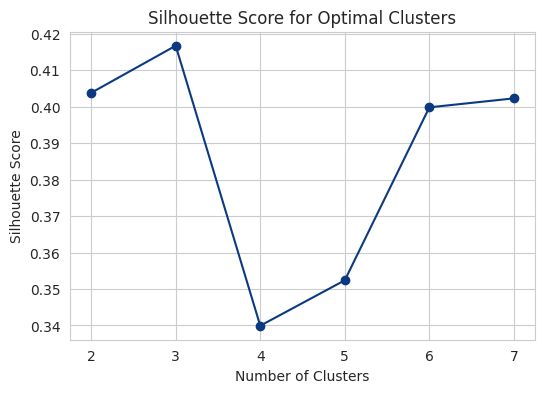

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

sil_scores = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_df["cluster"] = cluster_labels

eda_df.loc[cluster_df.index, "cluster"] = cluster_labels

/tmp/ipykernel_868/381097100.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


<Axes: xlabel='area_m2', ylabel='price_per_m2'>

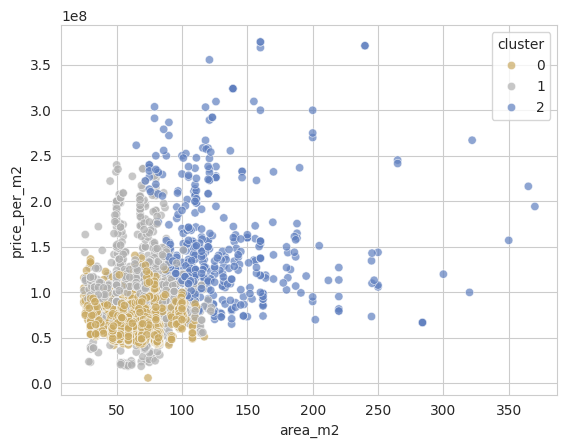

In [ ]:
sns.scatterplot(
    data=cluster_df,
    x="area_m2",
    y="price_per_m2",
    hue="cluster",
    palette=["#C9A961","#B0B0B0","#5F7FBF","#0B3A82"],
    alpha=0.7
)

In [ ]:
cluster_df.groupby("cluster").mean()

,area_m2,price_per_m2,dist_cbd_km,bedrooms,amenity_score
cluster,,,,,
0,63.307325,7.036314e+07,19.380523,1.924051,4.996733
1,70.496433,1.023428e+08,4.708278,1.900329,2.868204
2,131.302735,1.523541e+08,5.683408,3.188341,4.123318


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["cluster"] = cluster_labels

/tmp/ipykernel_868/480011082.py:3: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


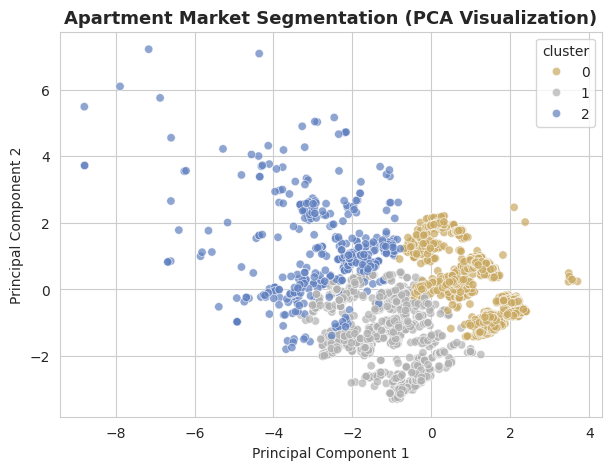

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=["#C9A961","#B0B0B0","#5F7FBF","#0B3A82"],
    alpha=0.7
)

plt.title("Apartment Market Segmentation (PCA Visualization)", fontsize=13, weight="bold")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
cluster_profile = cluster_df.groupby("cluster").mean()

cluster_profile

,area_m2,price_per_m2,dist_cbd_km,bedrooms,amenity_score
cluster,,,,,
0,63.307325,7.036314e+07,19.380523,1.924051,4.996733
1,70.496433,1.023428e+08,4.708278,1.900329,2.868204
2,131.302735,1.523541e+08,5.683408,3.188341,4.123318


In [ ]:
eda_df.groupby(["cluster", "brand"]).size()

cluster  brand   
0.0      Vinhomes    2449
1.0      Novaland     732
         Phát Đạt     104
         Vinhomes     378
2.0      Novaland      68
         Phát Đạt       3
         Vinhomes     375
dtype: int64

In [ ]:
# Giả sử dataframe của bạn tên là df
# Lưu file CSV

eda_df.to_csv("Batdongsan_eda_ver1.csv", index=False, encoding="utf-8-sig")

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1pgdDBf3L_MlpGnxAL4xeKMqDoNRYT6ID

Retrieving folder contents
Processing file 18IplzMQyBagCrzr5ftasmUUBawuUqgNf clean_novaland_all_sources_final.csv
Processing file 1t59OakC7kCDtEGoSH_y0np7wvKKnUrAG clean_phatdat_all_sources_final.csv
Processing file 1gSkaZcBqRjgqjeZyGkqTwi7TkOooyVeE clean_vinhomes_all_sources_final.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=18IplzMQyBagCrzr5ftasmUUBawuUqgNf
To: /content/Merge_data/clean_novaland_all_sources_final.csv
100% 2.82M/2.82M [00:00<00:00, 164MB/s]
Downloading...
From: https://drive.google.com/uc?id=1t59OakC7kCDtEGoSH_y0np7wvKKnUrAG
To: /content/Merge_data/clean_phatdat_all_sources_final.csv
100% 2.55M/2.55M [00:00<00:00, 187MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gSkaZcBqRjgqjeZyGkqTwi7TkOooyVeE
To: /content/Merge_data/clean_vinhomes_all_sources_final.csv
100% 4.55M/4.55M [00:00<00:00, 21.8MB/s]
Download completed


In [ ]:
# ======================
# 1. IMPORT LIBRARIES
# ======================
import pandas as pd
import numpy as np
import re
from collections import Counter

# ======================
# 2. LOAD DATA
# ======================
vin = pd.read_csv('/content/Merge_data/clean_vinhomes_all_sources_final.csv')
nova = pd.read_csv('/content/Merge_data/clean_novaland_all_sources_final.csv')
phat = pd.read_csv('/content/Merge_data/clean_phatdat_all_sources_final.csv')

# ======================
# 3. ADD BRAND
# ======================
vin['brand'] = 'Vinhomes'
nova['brand'] = 'Novaland'
phat['brand'] = 'Phát Đạt'

# ======================
# 4. MERGE
# ======================
df = pd.concat([vin, nova, phat], ignore_index=True)

# ======================
# 5. CLEAN DATA
# ======================

# chuẩn hóa tên cột
df.columns = df.columns.str.strip().str.lower()

# remove duplicate content (nếu có)
if 'is_duplicate_content' in df.columns:
    df = df[df['is_duplicate_content'] == False]

# combine text
df['text'] = (
    df['title'].fillna('') + ' ' + df['content_clean'].fillna('')
).str.lower()

# chuẩn hóa ngày
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['month'] = df['publish_date'].dt.to_period('M')

# ======================
# 6. VOLUME OF COVERAGE
# ======================
print("\n===== VOLUME OF COVERAGE =====")
volume = df['brand'].value_counts()
print(volume)

# ======================
# 7. KEYWORD ANALYSIS
# ======================

stopwords = set([
    'và','là','có','cho','các','của','được','trong','khi','với','tại',
    'đến','này','đó','một','những','về','đang','theo','từ','trên','ra',
    'dự','án','bất','động','sản','tp','hcm'
])

def get_top_words(text_series, n=15):
    words = []
    for text in text_series:
        tokens = re.findall(r'\b\w+\b', str(text))
        tokens = [w for w in tokens if w not in stopwords and len(w) > 2]
        words.extend(tokens)
    return Counter(words).most_common(n)

print("\n===== TOP KEYWORDS BY BRAND =====")

keyword_result = {}

for brand in df['brand'].unique():
    print(f"\n--- {brand} ---")
    top_words = get_top_words(df[df['brand'] == brand]['text'])
    keyword_result[brand] = top_words

    for word, count in top_words:
        print(f"{word}: {count}")

# ======================
# 8. TIMELINE
# ======================
print("\n===== TIMELINE (LAST MONTHS) =====")

timeline = df.groupby(['month', 'brand']).size().unstack().fillna(0)
print(timeline.tail(10))

# ======================
# 9. QUICK SUMMARY (TEXT)
# ======================
print("\n===== QUICK SUMMARY =====")

print("\nTop brand by coverage:")
print(volume.idxmax())

print("\nTotal articles per brand:")
print(volume.to_dict())

print("\nTop 5 keywords per brand:")
for brand, words in keyword_result.items():
    print(f"\n{brand}: {[w for w, c in words[:5]]}")

/tmp/ipykernel_868/3351672923.py:45: UserWarning: Parsing dates in %d-%m-%Y - %I:%M %p format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')



===== VOLUME OF COVERAGE =====
brand
Vinhomes    911
Novaland    642
Phát Đạt    553
Name: count, dtype: int64

===== TOP KEYWORDS BY BRAND =====

--- Vinhomes ---
vinhomes: 8094
đầu: 5862
thị: 5130
khu: 5006
công: 4890
đồng: 4385
thành: 3868
nhà: 3473
hàng: 3445
không: 3201
giá: 3015
năm: 2819
đại: 2736
triển: 2646
trường: 2493

--- Novaland ---
đồng: 6503
novaland: 4749
công: 4224
phiếu: 3647
năm: 3150
đầu: 2958
doanh: 2574
phát: 2343
thành: 2132
hơn: 2111
giá: 2097
hành: 1888
trái: 1768
ngày: 1657
hàng: 1654

--- Phát Đạt ---
phát: 5857
đạt: 4926
đồng: 4751
công: 4117
năm: 3359
đầu: 2958
doanh: 2875
phiếu: 2399
triển: 1982
thị: 1923
pdr: 1837
tăng: 1811
nghiệp: 1798
khu: 1721
giá: 1694

===== TIMELINE (LAST MONTHS) =====
brand    Novaland  Phát Đạt  Vinhomes
month                                
2025-06       8.0       2.0      19.0
2025-07       9.0       3.0       8.0
2025-08      12.0       1.0      13.0
2025-09      10.0       3.0      18.0
2025-10      12.0       5.0      21.0

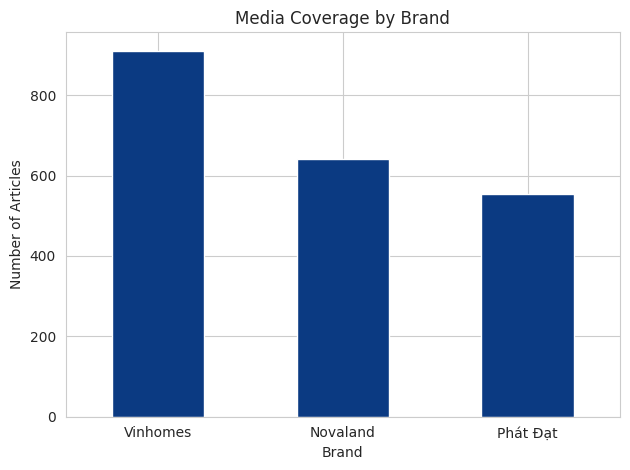

In [ ]:
import matplotlib.pyplot as plt

# ===== VOLUME BAR CHART =====
plt.figure()
volume.plot(kind='bar')
plt.title('Media Coverage by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

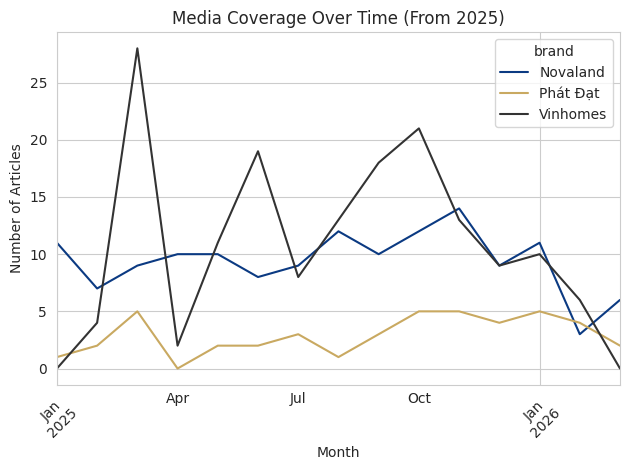

In [ ]:
# convert PeriodIndex -> DatetimeIndex
timeline.index = timeline.index.to_timestamp()

# lọc từ 2025 trở đi
timeline_2025 = timeline[timeline.index >= '2025-01-01']

# plot
timeline_2025.plot()
plt.title('Media Coverage Over Time (From 2025)')
plt.xlabel('Month')
plt.ylabel('Number of Articles')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()